In [2]:
import pandas as pd
import seaborn as sns  
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
import numpy as np

In [3]:
#1.- cargar informacion del dataset
df = pd.read_csv("diabetes.csv")

Datos

**Pregnancies**  |Embaraso

**Glucos**| azúcar en la sangre ||Los niveles en ayunas suelen ser de 76 mg/dL o menos, y después de las comidas,es mantenerlos por debajo de 140 mg/dL

**BloodPressure** |presion arterial |fuerza de la sangre contra las paredes de las arterias | es inferior a 120/80 mm Hg

**SkinThickness** | Espesor de la piel

**Insulin** |Insulina |es una hormona producida por el páncreas que permite a la glucosa entrar en las células para obtener energía|menos de 95 mg/dL (5.3 mmol/L) en ayunas y menos de 140 mg/dL (7.8 mmol/L) una hora después de las comidas

**BMI**|  cantidad de grasa corporal |medida que relaciona el peso y la altura de una persona| Bajo peso (IMC < 18,5) | Peso normal (IMC 18,5-24,9)| Sobrepeso (IMC 25,0-29,9)|Obesidad (IMC ≥ 30,0)

**DiabetesPedigreeFunction** | Prediccion de diabetes

**Age**| Edad de las participantes

**Outcome**| resultados | 1 tiene diabetes |0 no tiene diabetes

In [4]:
 #2.- generando el dataframe
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [5]:

df.head()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [6]:
print("Forma del datasett: ", df.shape)

print("\nColumnas del datasett: ", df.columns)


Forma del datasett:  (768, 9)

Columnas del datasett:  Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='str')


In [7]:
print("\nTipos de datos:")
df.dtypes


Tipos de datos:


Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

In [7]:
#3.- variables de describe()
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


**Insulina** |el promedio de 79.79 se encuentra por debajo del rango normal

**glucose**|se verifica que el promedio  es de 120.894531 se encuentra dentro del rango normal.

**BIM**|se encuentran es en el limite del sobrepeso

**BloodPressure** | presion baja

**age** edad promedio 33

VALORES ATIPICOS EN INSULINA YA QUE EL VALOR MAXIMO ESTA DEMASIADO LEJOS DEL 75% , EL STD ES MUY ALTA EN COMPARACION DE LA MEDIA LO QUE INDICARIA VALORES EXTREMOS Y TAMBIEN VALORES MINIMOS ES 0 EN OTROS CAMPOS NO SOLO EN GLUCOSA LO QUE INDICA QUE PROBABLEMENTE SON DATOS FALTENTES MAL CODIFICADOS

In [8]:
# 6.-valores nulos
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [9]:
# cuantos ceros hay por columna
(df == 0).sum()

Pregnancies                 111
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                     500
dtype: int64

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


# Distribución de clases de Outcome

In [11]:
#VALORES DE OUTCOME SEPARANDOLOS
conteo_resultado=df.Outcome.value_counts()
print(conteo_resultado)

Outcome
0    500
1    268
Name: count, dtype: int64


C:\Users\velar\AppData\Local\Temp\ipykernel_22160\4207194321.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Outcome', data=df, ax=ax[1], palette=['#3498db', '#e67e22'])


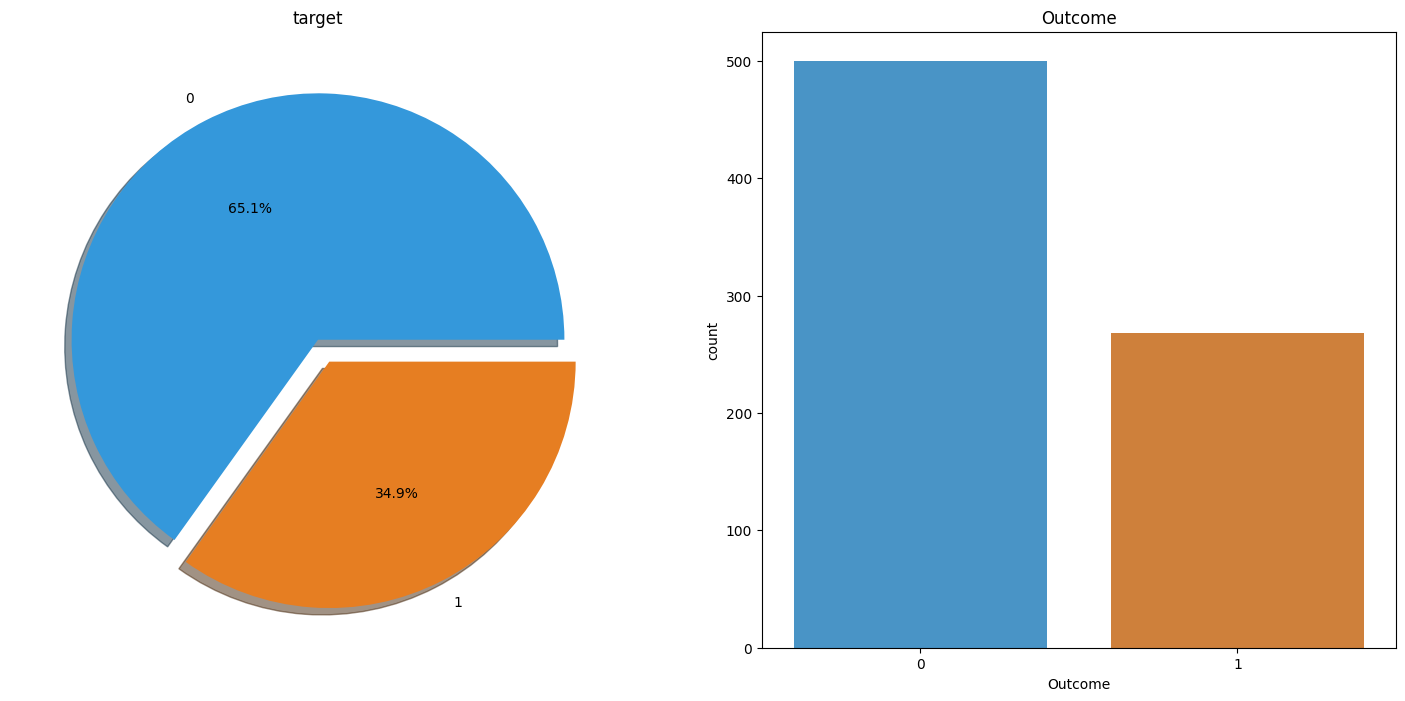

In [23]:
f, ax = plt.subplots(1, 2, figsize=(18, 8))
df['Outcome'].value_counts().plot.pie(explode=[0, 0.1],autopct='%1.1f%%',ax=ax[0],shadow=True,colors=['#3498db', '#e67e22'])
ax[0].set_title('target')
ax[0].set_ylabel('')

sns.countplot(x='Outcome', data=df, ax=ax[1], palette=['#3498db', '#e67e22'])
ax[1].set_title('Outcome')
plt.show()



**conclusion**

De la muestra toatal de la data Se visualiza que el 65.10% de las personas evaluadas no tiene diabetes  y el 34.9 % si tiene diabetes de

In [13]:
df_negativo = df[df['Outcome']==0]
df_positivo = df[df['Outcome']==1]
print(df_negativo.head(2))
print(df_positivo.head(2))

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
1            1       85             66             29        0  26.6   
3            1       89             66             23       94  28.1   

   DiabetesPedigreeFunction  Age  Outcome  
1                     0.351   31        0  
3                     0.167   21        0  
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
2            8      183             64              0        0  23.3   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
2                     0.672   32        1  


# HISTOGRAMAS
Se usaron para observar la distribución y posibles valores atípicos en cada variable clínica.

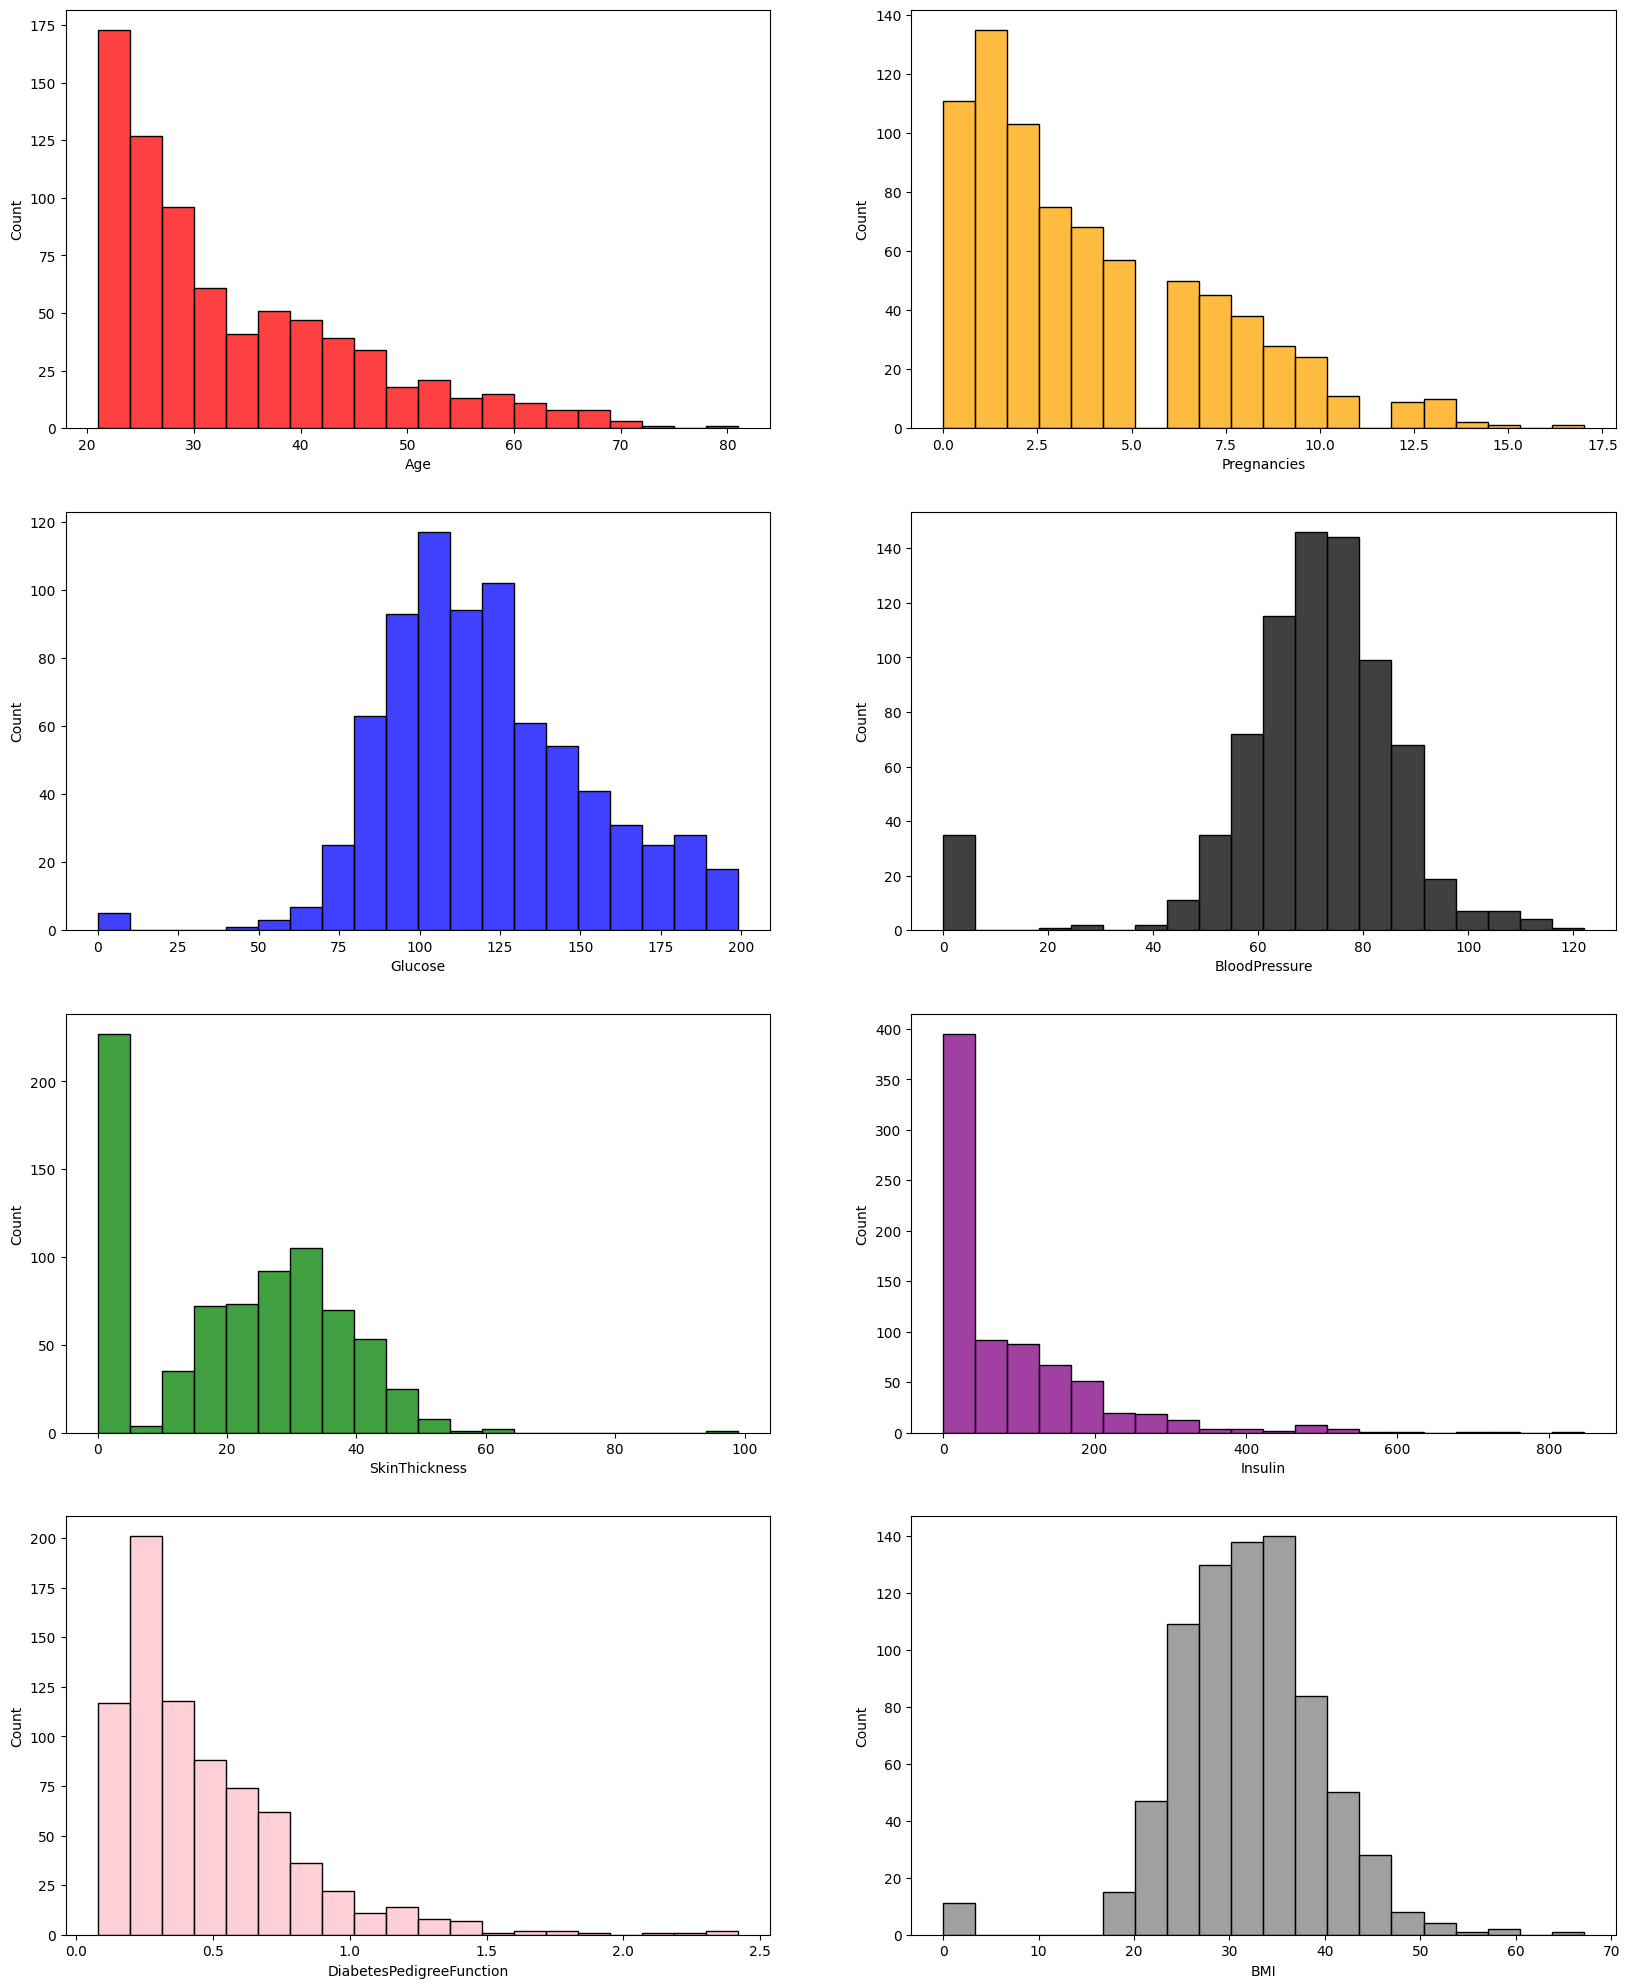

In [14]:
fig, ax = plt.subplots(4, 2, figsize=(20, 25))

sns.histplot(df['Age'], bins=20, color='red', ax=ax[0,0], edgecolor='black')
sns.histplot(df['Pregnancies'], bins=20, color='orange', ax=ax[0,1], edgecolor='black')
sns.histplot(df['Glucose'], bins=20, color='blue', ax=ax[1,0], edgecolor='black')
sns.histplot(df['BloodPressure'], bins=20, color='black', ax=ax[1,1], edgecolor='black')
sns.histplot(df['SkinThickness'], bins=20, color='green', ax=ax[2,0], edgecolor='black')
sns.histplot(df['Insulin'], bins=20, color='purple', ax=ax[2,1], edgecolor='black')
sns.histplot(df['DiabetesPedigreeFunction'], bins=20, color='pink', ax=ax[3,0], edgecolor='black')
sns.histplot(df['BMI'], bins=20, color='gray', ax=ax[3,1], edgecolor='black')

plt.show()

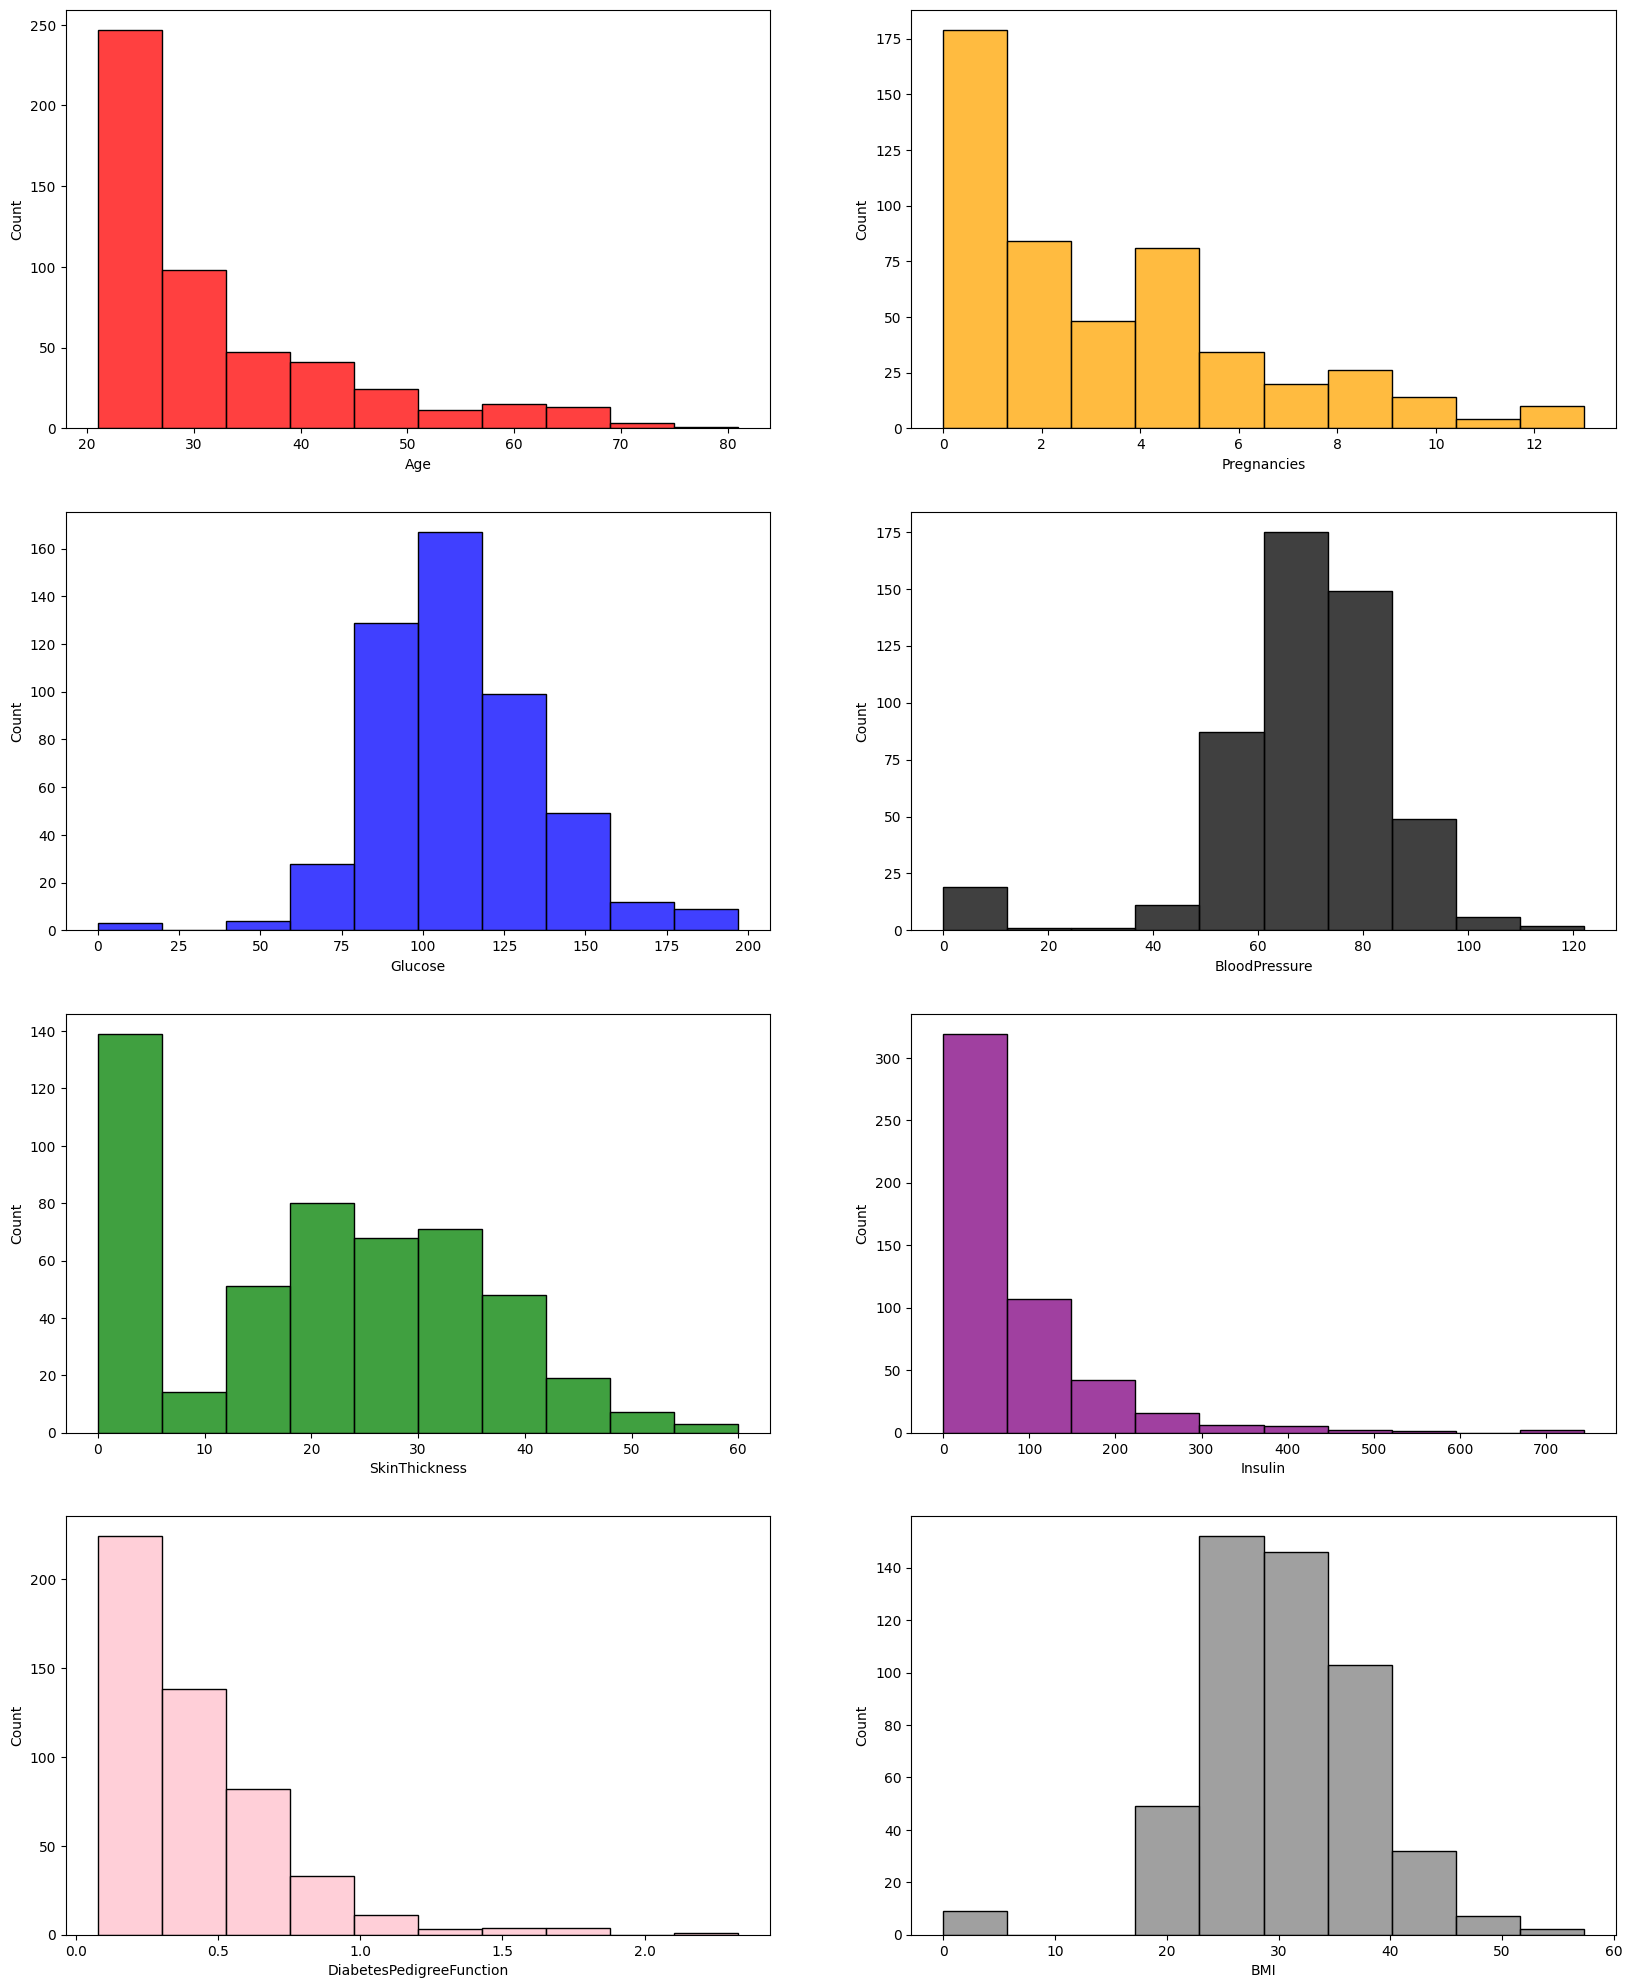

In [15]:

fig, ax = plt.subplots(4, 2, figsize=(20, 25))
sns.histplot(df_negativo['Age'], bins=10, color='red', ax=ax[0,0], edgecolor='black')
sns.histplot(df_negativo['Pregnancies'], bins=10, color='orange', ax=ax[0,1], edgecolor='black')
sns.histplot(df_negativo['Glucose'], bins=10, color='blue', ax=ax[1,0], edgecolor='black')
sns.histplot(df_negativo['BloodPressure'], bins=10, color='black', ax=ax[1,1], edgecolor='black')
sns.histplot(df_negativo['SkinThickness'], bins=10, color='green', ax=ax[2,0], edgecolor='black')
sns.histplot(df_negativo['Insulin'], bins=10, color='purple', ax=ax[2,1], edgecolor='black')
sns.histplot(df_negativo['DiabetesPedigreeFunction'], bins=10, color='pink', ax=ax[3,0], edgecolor='black')
sns.histplot(df_negativo['BMI'], bins=10, color='gray', ax=ax[3,1], edgecolor='black')

plt.show()

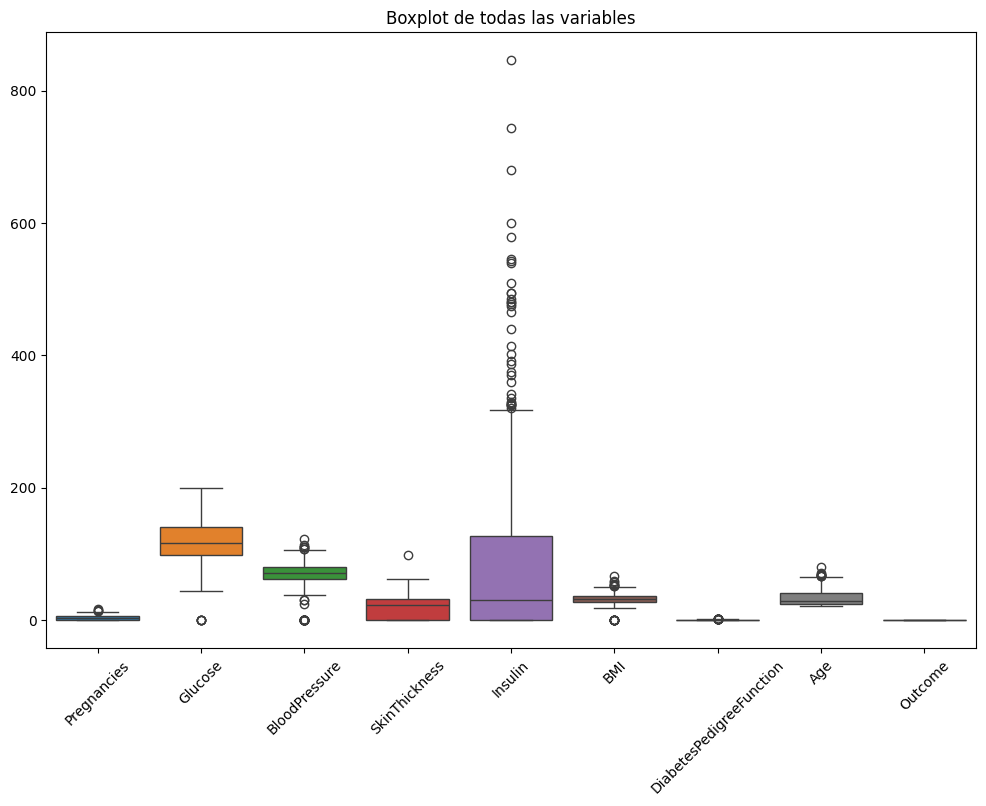

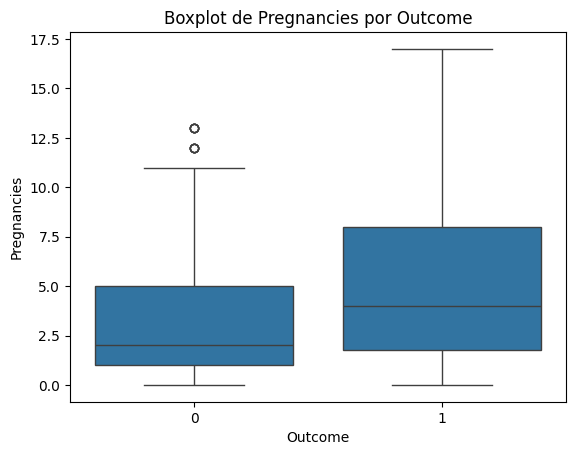

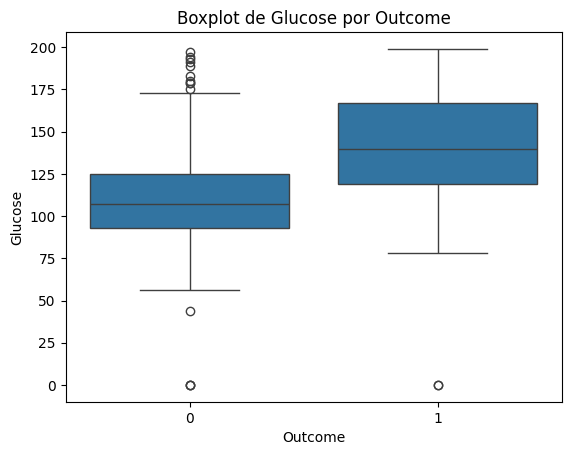

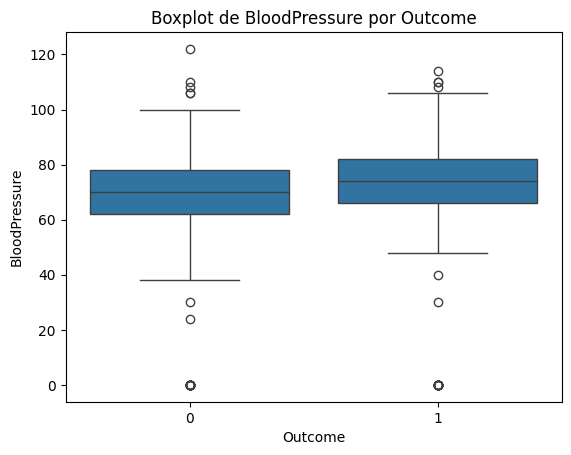

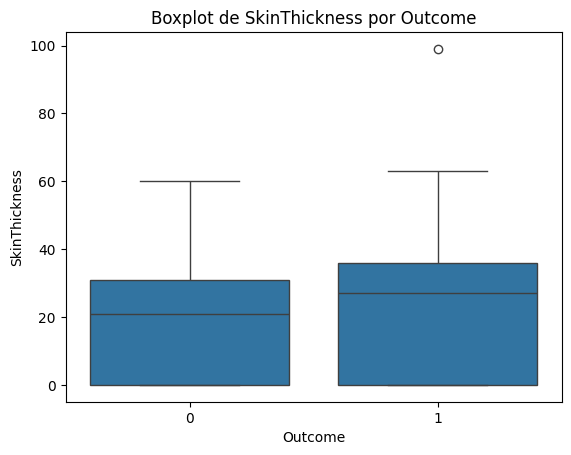

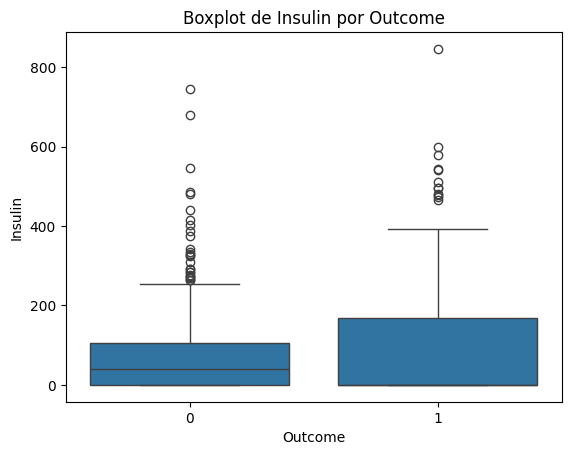

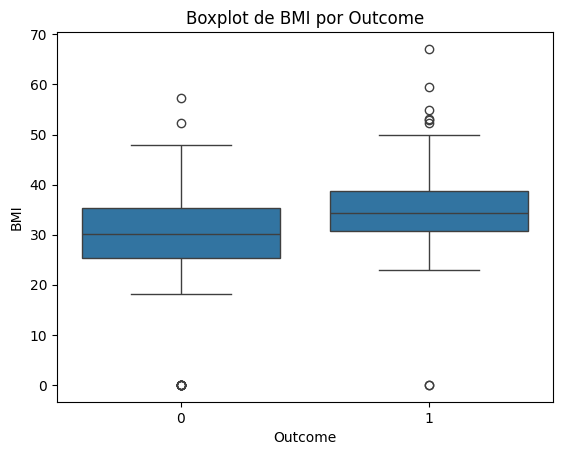

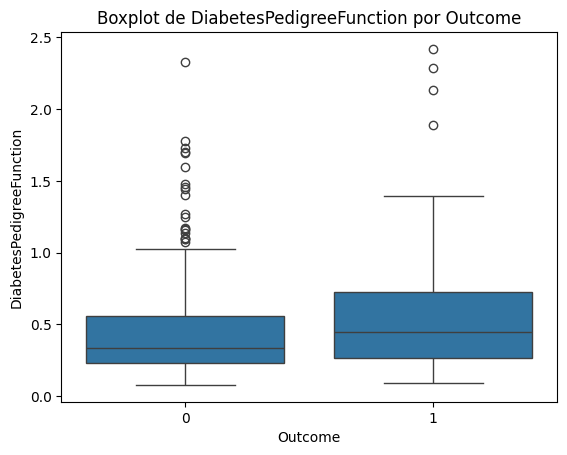

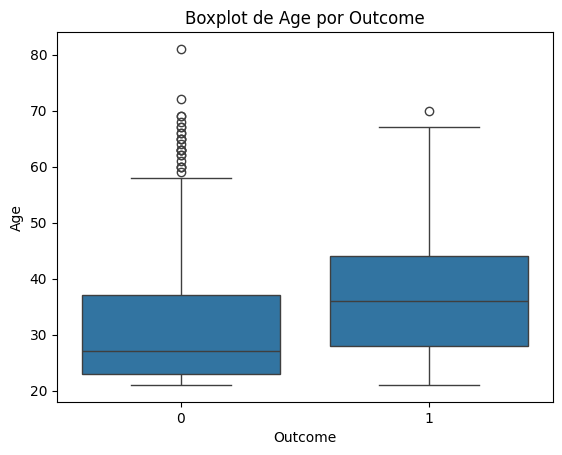

In [16]:
plt.figure(figsize=(12, 8))
sns.boxplot(data=df)
plt.title('Boxplot de todas las variables')
plt.xticks(rotation=45)
plt.show()

columnas = df.columns.drop('Outcome')
for col in columnas:
    sns.boxplot(x='Outcome', y=col, data=df)
    plt.title(f'Boxplot de {col} por Outcome')
    plt.show()

** conclusion**

se observa que de las variables analizadas todas tienen valores atipicos
* en la variable BIM  no cuenta con muchos valores atipicos
* en la variable glucosa no hay muchos valores atipicos debido que la glucosa alta es considerada diabetes
* en la variable insulina tenemos muchos valores atipicos debido que insulina cero es considerado como diabetes.

In [17]:
# Definir función para filtrar columnas por correlación
def preprocesar_por_correlacion(df, target='Outcome', threshold=0.1, mostrar_heatmap=True):
    if mostrar_heatmap:
        plt.figure(figsize=(10, 8))
        sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
        plt.title('Correlation Heatmap')
        plt.show()

    # Calcular correlaciones con la variable objetivo
    correlaciones = df.corr()[target].drop(target)
    columnas_eliminadas = correlaciones[correlaciones.abs() < threshold].index.tolist()

    print(f'\nEliminando columnas con correlación < {threshold}: {columnas_eliminadas}')

    # Eliminar columnas si existen
    df_filtrado = df.drop(columns=[col for col in columnas_eliminadas if col in df.columns], errors='ignore')

    # Separar X e y
    X = df_filtrado.drop(target, axis=1)
    Y = df_filtrado[target]

    print(f'\n✅ Columnas finales en X: {X.columns.tolist()}')

    return df_filtrado, X, Y, columnas_eliminadas

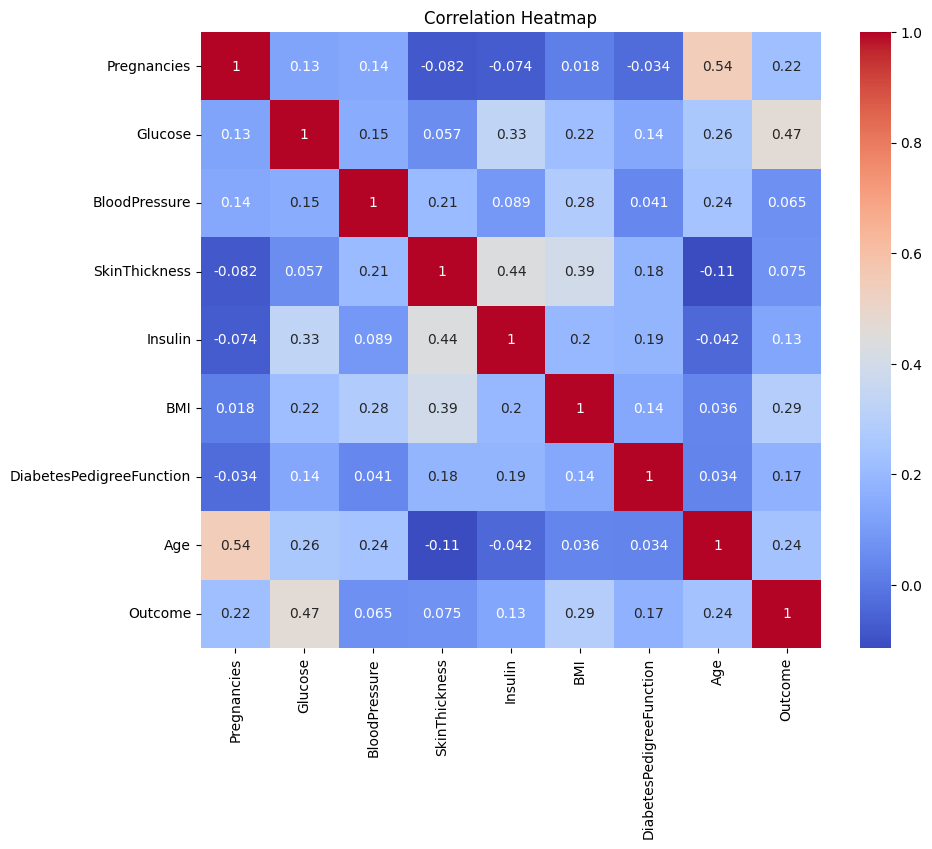


Eliminando columnas con correlación < 0.1: ['BloodPressure', 'SkinThickness']

✅ Columnas finales en X: ['Pregnancies', 'Glucose', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

Verificación: X tiene 6 columnas: ['Pregnancies', 'Glucose', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']


In [18]:

# Aplicar preprocesamiento para filtrar columnas
df_filtrado, X, Y, eliminadas = preprocesar_por_correlacion(df, target='Outcome', threshold=0.1)

# Verificar que X está definido
print(f'\nVerificación: X tiene {X.shape[1]} columnas: {X.columns.tolist()}')

In [19]:
cols_con_cero = ['Glucose', 'Insulin', 'BMI']
df[cols_con_cero] = df[cols_con_cero].replace(0, np.nan)
for col in cols_con_cero:
    df[col] = df.groupby('Outcome')[col].transform(lambda x: x.fillna(x.median()))

print('Nulos despues del manejo:')
print(df.isnull().sum())

Nulos despues del manejo:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [20]:
# Split data
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=42)

# Logistic Regression
log_reg = LogisticRegression()
log_reg.fit(X_train, Y_train)
log_pred = log_reg.predict(X_test)

# SVC
svc = SVC(probability=True)
svc.fit(X_train, Y_train)
svc_pred = svc.predict(X_test)

In [21]:
log_acc = accuracy_score(Y_test, log_pred)
log_auc = roc_auc_score(Y_test, log_reg.predict_proba(X_test)[:, 1])

svc_acc = accuracy_score(Y_test, svc_pred)
svc_auc = roc_auc_score(Y_test, svc.predict_proba(X_test)[:, 1])

print('Regresión logistica:')
print(f'Accuracy: {log_acc:.2f}, ROC AUC: {log_auc:.2f}')
print(classification_report(Y_test, log_pred))

print('SVC:')
print(f'Accuracy: {svc_acc:.2f}, ROC AUC: {svc_auc:.2f}')
print(classification_report(Y_test, svc_pred))

Regresión logistica:
Accuracy: 0.74, ROC AUC: 0.79
              precision    recall  f1-score   support

           0       0.79      0.81      0.80       151
           1       0.63      0.59      0.61        80

    accuracy                           0.74       231
   macro avg       0.71      0.70      0.70       231
weighted avg       0.73      0.74      0.73       231

SVC:
Accuracy: 0.74, ROC AUC: 0.76
              precision    recall  f1-score   support

           0       0.76      0.87      0.81       151
           1       0.67      0.47      0.55        80

    accuracy                           0.74       231
   macro avg       0.71      0.67      0.68       231
weighted avg       0.73      0.74      0.72       231

